# Comparing lines with SDSS

In [1]:
import os
import sys
magePath = '/home/benjamin/Documents/analogs/'
os.sys.path.append(magePath)

import numpy as np
import matplotlib.pyplot as plt
from magE.constutils import specobjID
from magE.plotutils import *

In [2]:
gals = ['J0023', 'J0136', 'J0252', 'J0305', 'J2212', 'J2337']
galobjID = []

for gal in gals:
    galobjID.append(str(specobjID[gal]))
    
from astropy.io import fits
spec_line = fits.open('/home/benjamin/Documents/MPA-JHU/galSpecLine-dr8.fits')

In [3]:
nii_sdss = []
nii_sdss_err = []

ha_sdss = []
ha_sdss_err = []

oiii_sdss = []
oiii_sdss_err = []

hb_sdss = []
hb_sdss_err = []

for objID in galobjID:
    mask = (spec_line[1].data['SPECOBJID'] == objID)
    
    nii_sdss.append(spec_line[1].data['NII_6584_FLUX'][mask][0])
    nii_sdss_err.append(spec_line[1].data['NII_6584_FLUX_ERR'][mask][0])
    
    ha_sdss.append(spec_line[1].data['H_ALPHA_FLUX'][mask][0])
    ha_sdss_err.append(spec_line[1].data['H_ALPHA_FLUX_ERR'][mask][0])
    
    oiii_sdss.append(spec_line[1].data['OIII_5007_FLUX'][mask][0])
    oiii_sdss_err.append(spec_line[1].data['OIII_5007_FLUX_ERR'][mask][0])
    
    hb_sdss.append(spec_line[1].data['H_BETA_FLUX'][mask][0])
    hb_sdss_err.append(spec_line[1].data['H_BETA_FLUX_ERR'][mask][0])

In [4]:
import uncertainties.umath as uum
from uncertainties import ufloat
from uncertainties import unumpy

nii_sdss_arr = unumpy.uarray(nii_sdss, nii_sdss_err)
ha_sdss_arr = unumpy.uarray(ha_sdss, ha_sdss_err)
oiii_sdss_arr = unumpy.uarray(oiii_sdss, oiii_sdss_err)
hb_sdss_arr = unumpy.uarray(hb_sdss, hb_sdss_err)

In [5]:
# J0023, J0136, J0252, J0305, J2212, J2337
mes_nii_arr = unumpy.uarray([1.1220746537742492e-15, 3.411984322078088e-16, 3.5636683324448007e-16, 9.30642838757682e-16, 8.781299170063142e-16, 6.06125254210518e-16],
                             [1.6269573974519185e-17, 1.0197273882908588e-17, 1.0290716800730053e-17, 1.324227370864389e-17, 1.574079879544911e-17, 9.024008434249211e-18])

mes_ha_arr = unumpy.uarray([5.607195830221245e-14, 2.315853330252105e-14, 2.3949169489007914e-14, 2.0936542539583413e-14, 1.4638132144513357e-14, 4.231856220572534e-14],
                           [9.51838160242679e-17, 4.6838388145782424e-17, 4.9910742854970646e-17, 4.114282091340892e-17, 3.088943060879417e-17, 5.4351218224287107e-17])

mes_oiii_arr = unumpy.uarray([1.0796163420033748e-13, 5.926024554954652e-14, 5.859488725972952e-14, 3.4825799874975506e-14, 2.3563874925095167e-14, 9.374598024442607e-14],
                             [1.6570864510215688e-16, 1.0106086817407922e-16, 9.501772697689289e-17, 5.917775283182399e-17, 4.619063283249815e-17, 9.468615552403306e-17])

mes_hb_arr = unumpy.uarray([1.4471173539893492e-14, 7.312052061500343e-15, 8.31717179090257e-15, 5.951772128501248e-15, 4.289697242324622e-15, 1.2803868032529185e-14],
                           [5.467353807029606e-17, 3.241712551856892e-17, 4.1790723411534744e-17, 2.7521202802204244e-17, 2.0062483294094676e-17, 3.343066944965122e-17])

In [6]:
# J0023, J2212
new_nii_arr = unumpy.uarray([7.78380376014774e-16, 3.604090915699258e-16],
                             [5.842723411830447e-18, 6.347245027980789e-18])

new_ha_arr = unumpy.uarray([3.14392815437561e-14, 6.7645021038670764e-15],
                           [3.339591756135906e-17, 1.6478272515109393e-17])

new_oiii_arr = unumpy.uarray([4.7250374626583056e-14, 1.0626086383406573e-14],
                             [8.174302217807485e-17, 2.2047262679972947e-17])

new_hb_arr = unumpy.uarray([8.512636242226169e-15, 1.965764717251243e-15],
                           [2.4191540125418603e-17, 1.0744479378711155e-17])

In [7]:
nii_ha_sdss = nii_sdss_arr / ha_sdss_arr
oiii_hb_sdss = oiii_sdss_arr / hb_sdss_arr
ha_hb_sdss = ha_sdss_arr / hb_sdss_arr

mes_nii_ha = mes_nii_arr / mes_ha_arr
mes_oiii_hb = mes_oiii_arr / mes_hb_arr
mes_ha_hb = mes_ha_arr / mes_hb_arr

new_nii_ha = new_nii_arr / new_ha_arr
new_oiii_hb = new_oiii_arr / new_hb_arr
new_ha_hb = new_ha_arr / new_hb_arr

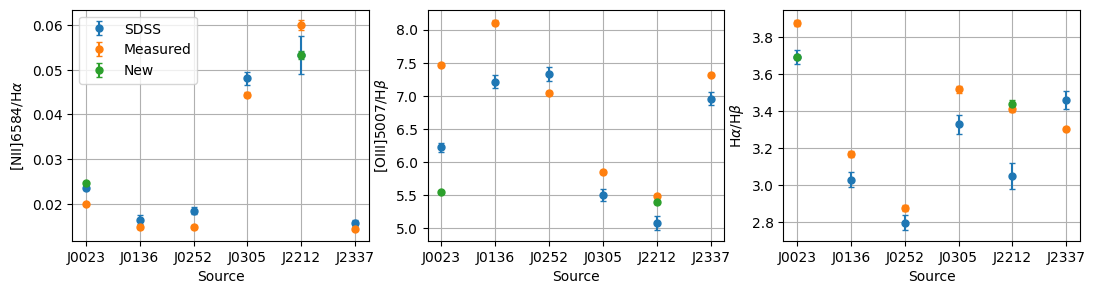

In [10]:
fig, axs = plt.subplots(1, 3)
fig.set_size_inches((13, 3))

axs[0].errorbar(gals, unumpy.nominal_values(nii_ha_sdss), unumpy.std_devs(nii_ha_sdss),
                marker='o', ms=5, capsize=2, ls='', label='SDSS')
axs[0].errorbar(gals, unumpy.nominal_values(mes_nii_ha), unumpy.std_devs(mes_nii_ha),
                marker='o', ms=5, capsize=2, ls='', label='Measured')
axs[0].errorbar(['J0023', 'J2212'], unumpy.nominal_values(new_nii_ha), unumpy.std_devs(new_nii_ha),
                marker='o', ms=5, capsize=2, ls='', label='New')

axs[0].grid()
axs[0].set_xlabel('Source')
axs[0].set_ylabel(r'[NII]6584/H$\alpha$')


axs[1].errorbar(gals, unumpy.nominal_values(oiii_hb_sdss), unumpy.std_devs(oiii_hb_sdss),
                marker='o', ms=5, capsize=2, ls='', label='SDSS')
axs[1].errorbar(gals, unumpy.nominal_values(mes_oiii_hb), unumpy.std_devs(mes_oiii_hb),
                marker='o', ms=5, capsize=2, ls='', label='Measured')
axs[1].errorbar(['J0023', 'J2212'], unumpy.nominal_values(new_oiii_hb), unumpy.std_devs(new_oiii_hb),
                marker='o', ms=5, capsize=2, ls='', label='New')

axs[1].grid()
axs[1].set_xlabel('Source')
axs[1].set_ylabel(r'[OIII]5007/H$\beta$')


axs[2].errorbar(gals, unumpy.nominal_values(ha_hb_sdss), unumpy.std_devs(ha_hb_sdss),
                marker='o', ms=5, capsize=2, ls='', label='SDSS')
axs[2].errorbar(gals, unumpy.nominal_values(mes_ha_hb), unumpy.std_devs(mes_ha_hb),
                marker='o', ms=5, capsize=2, ls='', label='Measured')
axs[2].errorbar(['J0023', 'J2212'], unumpy.nominal_values(new_ha_hb), unumpy.std_devs(new_ha_hb),
                marker='o', ms=5, capsize=2, ls='', label='New')
axs[2].grid()
axs[2].set_xlabel('Source')
axs[2].set_ylabel(r'H$\alpha$/H$\beta$')
axs[0].legend(loc='upper left', frameon=True)
#fig.savefig('sdss_vs_mes.png', bbox_inches='tight', facecolor='white')

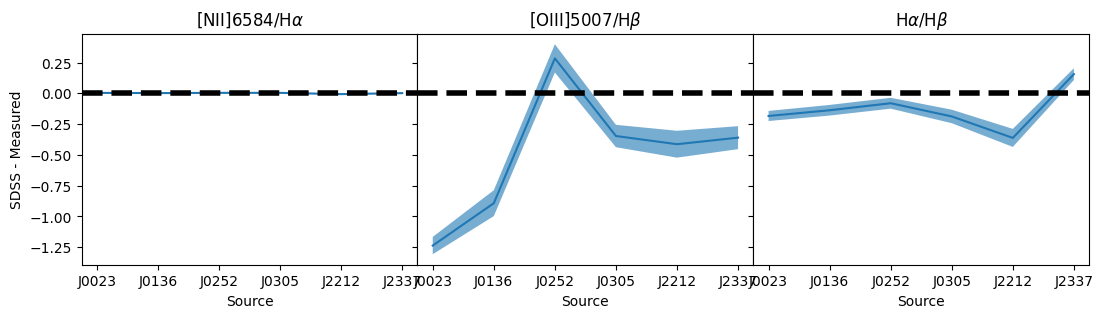

In [9]:
fig, axs = plt.subplots(1, 3, sharey=True)
fig.set_size_inches((13, 3))

axs[0].plot(gals, unumpy.nominal_values(nii_ha_sdss - mes_nii_ha))
axs[0].fill_between(gals, unumpy.nominal_values(nii_ha_sdss - mes_nii_ha) - unumpy.std_devs(nii_ha_sdss - mes_nii_ha),
                          unumpy.nominal_values(nii_ha_sdss - mes_nii_ha) + unumpy.std_devs(nii_ha_sdss - mes_nii_ha),
                   alpha = 0.6)
axs[0].axhline(0, ls='--', lw=4, color='black')
axs[0].set_xlabel('Source')
axs[0].set_ylabel('SDSS - Measured')
axs[0].set_title(r'[NII]6584/H$\alpha$')


axs[1].plot(gals, unumpy.nominal_values(oiii_hb_sdss - mes_oiii_hb))
axs[1].fill_between(gals, unumpy.nominal_values(oiii_hb_sdss - mes_oiii_hb) - unumpy.std_devs(oiii_hb_sdss - mes_oiii_hb),
                          unumpy.nominal_values(oiii_hb_sdss - mes_oiii_hb) + unumpy.std_devs(oiii_hb_sdss - mes_oiii_hb),
                   alpha = 0.6)
axs[1].axhline(0, ls='--', lw=4, color='black')
axs[1].set_xlabel('Source')
axs[1].set_title(r'[OIII]5007/H$\beta$')


axs[2].plot(gals, unumpy.nominal_values(ha_hb_sdss - mes_ha_hb))
axs[2].fill_between(gals, unumpy.nominal_values(ha_hb_sdss - mes_ha_hb) - unumpy.std_devs(ha_hb_sdss - mes_ha_hb),
                          unumpy.nominal_values(ha_hb_sdss - mes_ha_hb) + unumpy.std_devs(ha_hb_sdss - mes_ha_hb),
                   alpha = 0.6)
axs[2].axhline(0, ls='--', lw=4, color='black')
axs[2].set_xlabel('Source')
axs[2].set_title(r'H$\alpha$/H$\beta$')
plt.subplots_adjust(wspace=0)
#fig.savefig('sdss_mes_diff.png', bbox_inches='tight', facecolor='white')